# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries and data

In [1]:
# Installing the libraries with the specified version.
!pip install numpy pandas scikit-learn==1.5.2 matplotlib seaborn xgboost==2.0.3 -q

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
#Code for necessary libraries
#Code to ignore warnings
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

In [3]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [4]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [5]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [6]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [7]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [8]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [9]:
#Code to mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Code to read data
original_data = pd.read_csv("/content/drive/MyDrive/Python/P5/EasyVisa.csv")

In [11]:
#Code to make a copy of data to avoid any changes to original data
df = original_data.copy()

## Data Overview

- Observations
- Sanity checks

In [12]:
#Code to view top 5 rows of the data
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [13]:
#Code to view last 5 rows of the data
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


* Data appears to be imported correctly




In [14]:
#Code to view dimensions/shape of the data
df.shape

(25480, 12)

* There are 25480 rows and 12 columns

In [15]:
#Code to check the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* There are 3 numeric columns (1 float and 2 int64) and 9 object datatype columns
* There do not appear to be any missing values


In [16]:
#Code to check for duplicate values
df.duplicated().sum()

0

* No duplicated values

In [17]:
#Code to drop Case ID because it isn't relevent
df.drop("case_id", axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

In [18]:
#Code to view the statistical summary of the data
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_time_position,25480,2,Y,22773,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observations:
* Target variable is Case Status
* The minimum for number of employees is negative which is concerning and needs to be corrected since that isn't possible.
* The mean prevailing wage is $74455.81. There is quite a large range for this variable from ~2 to ~320k.
* There are 6 continents represented, which means all habitable continents are represented, with Asia being the most frequent
* There are 5 regions, of which the Northeast is the most frequent
* Bachelor's is the most frequent level of education
* Most do not require job training
* Most are for full time positions
* Year is the most frequent unit of wage


In [19]:
#Code to check negatives in number of employees column
df.loc[df['no_of_employees']<0].shape

(33, 11)

* There are 33 observations with negatives. Let's fix this by taking the absolute value.

In [20]:
#Code to take the absolute value for number of employees
df["no_of_employees"] = abs(df["no_of_employees"])

* Now that it's corrected, the minimum number of employees is 11

In [21]:
# Making a list of all categorical variables
cat_col = list(df.select_dtypes("category").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 50)

* Asia is the most frequent continent, followed by Europe and North America. Not very many applicants from Oceania comparatively.
* Bachelor's is the most frequent level of education, but Master's follws very closely. Those two make up the majority.
* Most frequent region is Northeast, closely followed by the South and West

Univariate Analysis

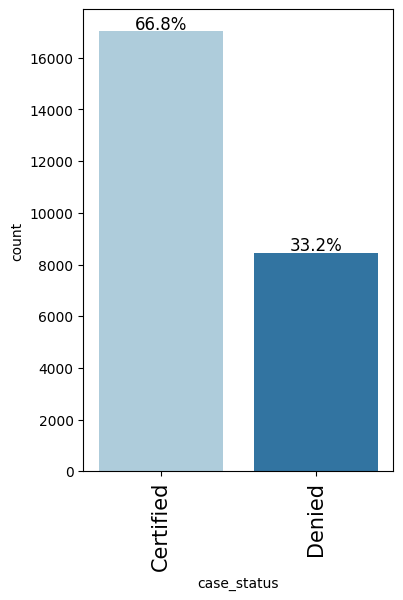

In [22]:
#Code for labeled barplot of case status
labeled_barplot(df, "case_status", perc=True)

* Appears that around 2/3 of the cases were certified, while 1/3 were denied.

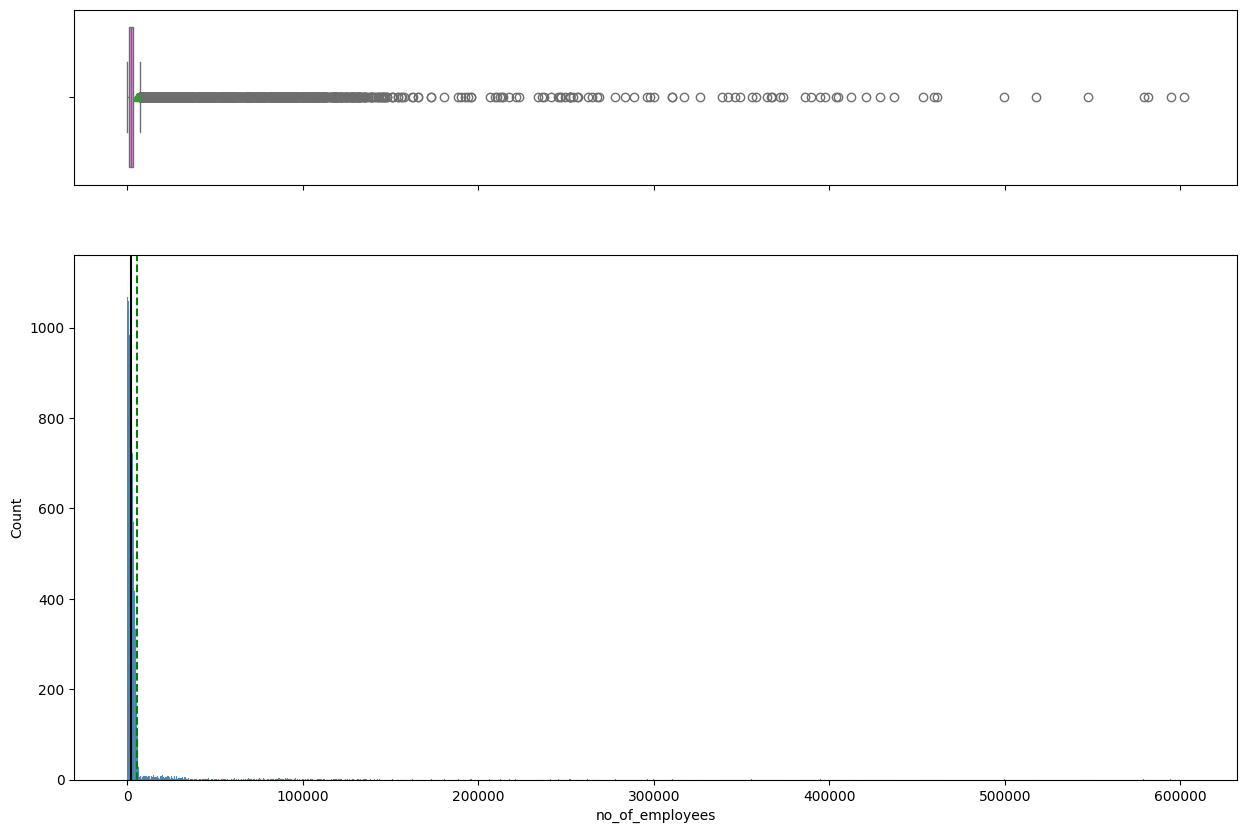

In [23]:
#Code for histogram_boxplot for number of employees
histogram_boxplot(df, "no_of_employees")

* Very right-skewed

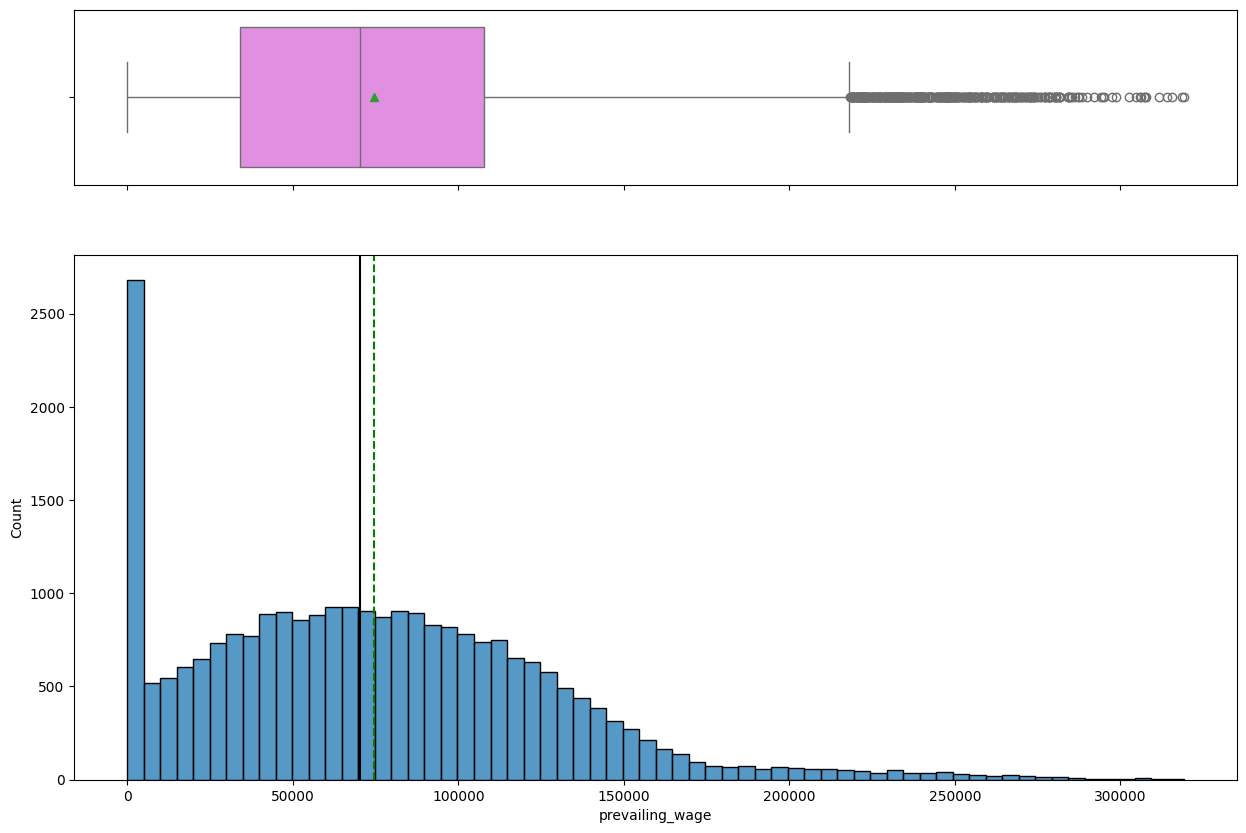

In [24]:
#Code for histogram_boxplot for prevailing wage
histogram_boxplot(df, "prevailing_wage")

* A bit skewed to the right
* The mean and median look to be in the 70k region

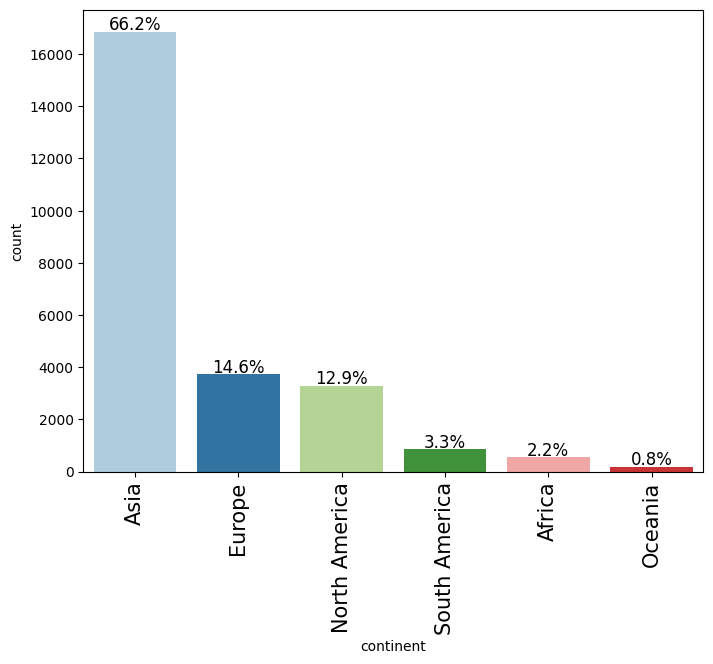

In [25]:
#Code for labeled_barplot for continent
labeled_barplot(df, "continent", perc=True)

* Most applicants, about 2/3, are from Asia

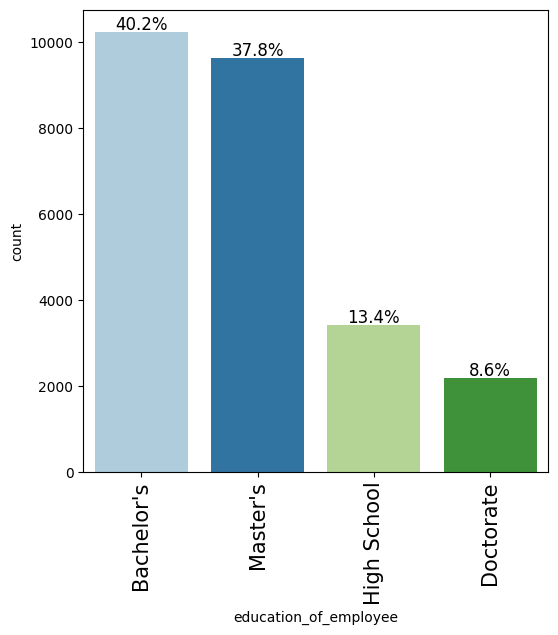

In [26]:
#Code for labeled_barplot for education of employee
labeled_barplot(df, "education_of_employee", perc=True)

* 40.2% have a Bachelor's degree and 37.8% have a Master's.
* Most applicants have at least a Bachelor's degree.

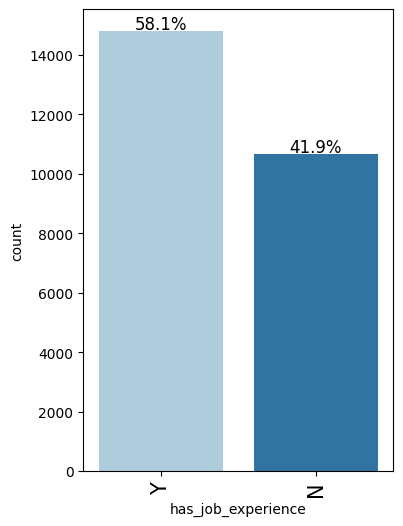

In [27]:
#Code for labeled_barplot for job experience
labeled_barplot(df, "has_job_experience", perc=True)

* More applicants have job experience than those who don't.
* Though, the percentages are close with 58.1% having job experience and 41.9% not.

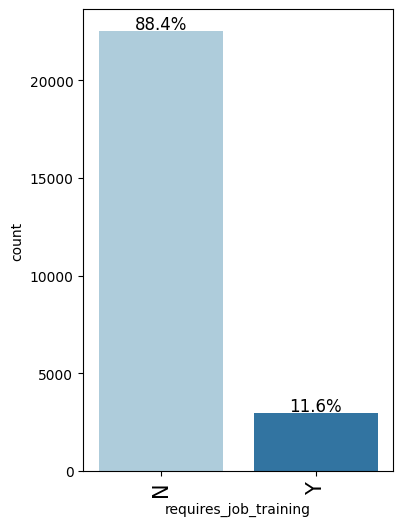

In [28]:
#Code for labeled_barplot for requires_job_training
labeled_barplot(df, "requires_job_training", perc=True)

* 88.4% don't require job training, so its appears that most of the jobs don't require it.

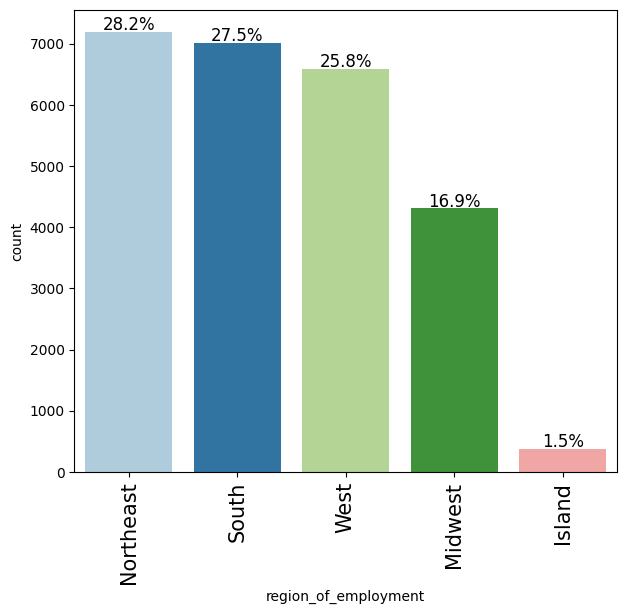

In [29]:
#Code for labeled_barplot for region_of_employment
labeled_barplot(df, "region_of_employment", perc=True)

* Northeast, South, and West are all pretty close for higher percentages of applications for those regions.
* The Island region appears to be quite low for percentages of applications.

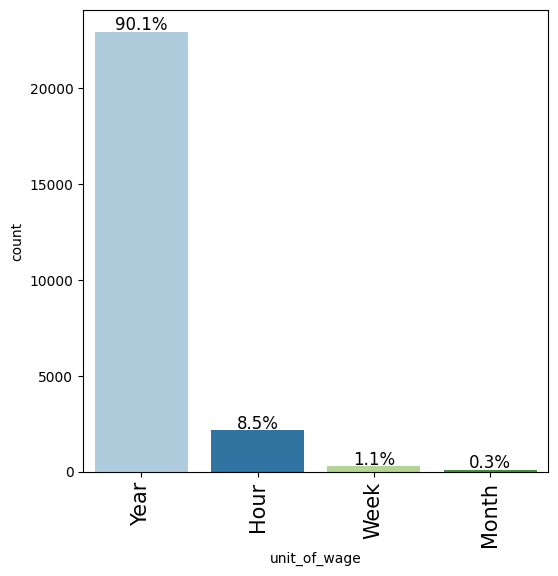

In [30]:
#Code for labeled_barplot for unit_of_wage
labeled_barplot(df, "unit_of_wage", perc=True)

* 90.1% of applications had year for unit of wage, so year seems to be the more standard unit

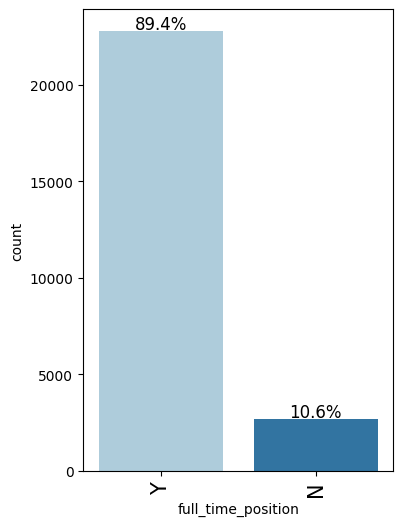

In [31]:
#Code for labeled_barplot for full_time_position
labeled_barplot(df, "full_time_position", perc=True)

* An overwhelming majority, 89.4%, of applications were for full time positions

Bivariate Analysis

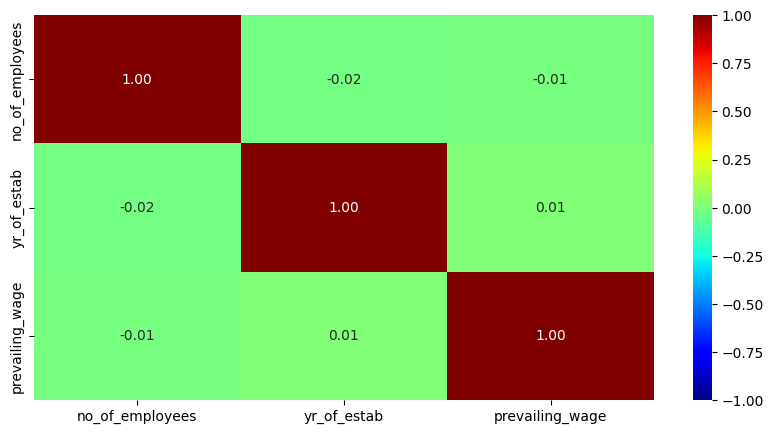

In [32]:
#Code for heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only = True),annot=True,vmin=-1,vmax=1,fmt='.2f',cmap="jet")
plt.show()

* Doesn't appear to be any correlation between the numeric variables

Q.1 Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


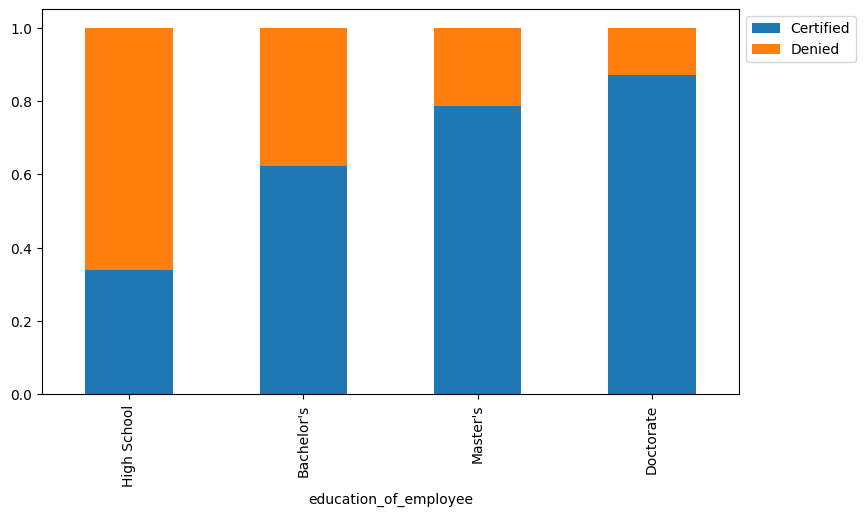

In [33]:
#Code for plot of Education vs Case Status
stacked_barplot(df, "education_of_employee", "case_status")

* Definitely appears that level of education may play a role in certification as we can see an increase in certifications with each increase in level of education.

Q.2 How does the visa status vary across different continents?



case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


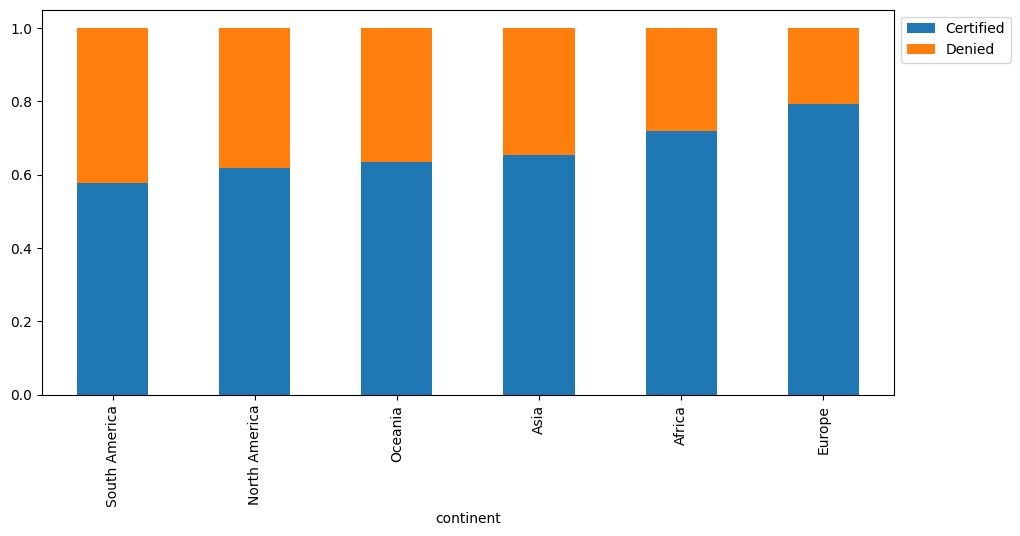

In [34]:
#Code for plot of Continent vs Case Status
stacked_barplot(df, "continent", "case_status")

* Visa certifications seem fairly consitent between continents, though maybe a little less for South America

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


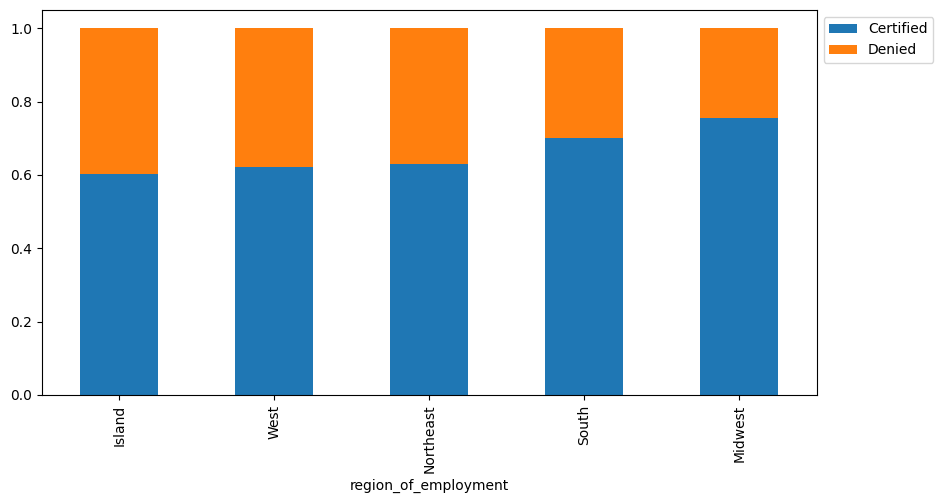

In [35]:
#Let's have a look at the percentage of visa certifications across each region
#Code to plot Region of Employment vs Case Status
stacked_barplot(df, "region_of_employment", "case_status")

* Certification also seems consistent between different regions, though the Midwest and South look to have a slight edge.

Q.3 Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?



case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


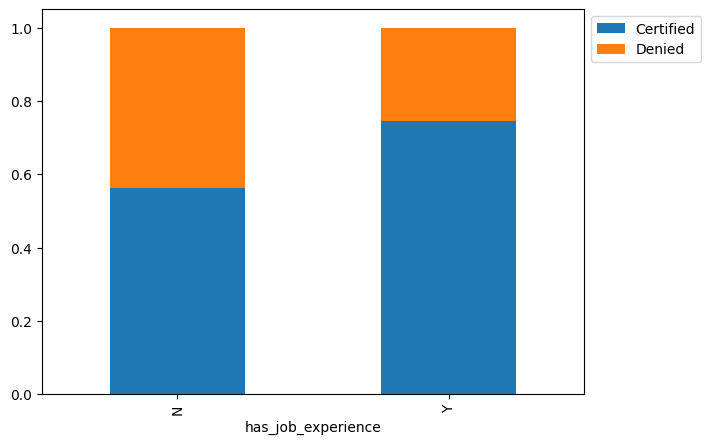

In [36]:
#Code for plot of Job Experience vs Case Status
stacked_barplot(df, "has_job_experience", "case_status")

* A higher percentage of applicants with job experience were certified compared to those without job experience.

Q.4 In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?



case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


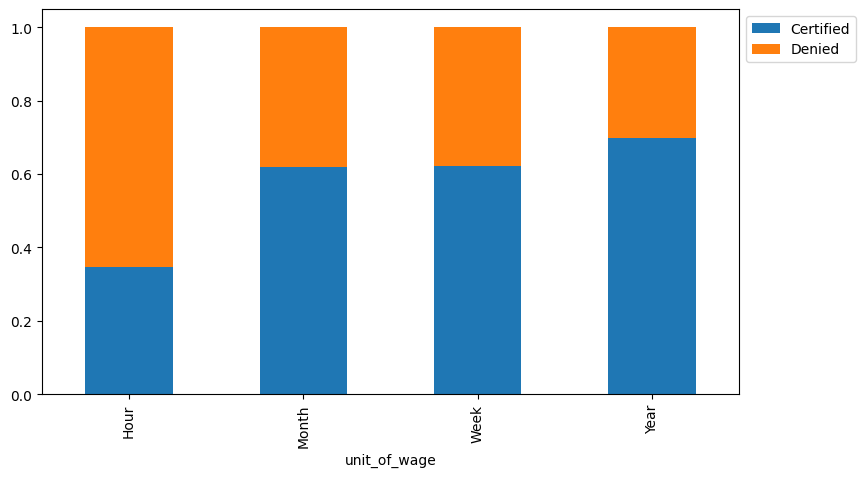

In [37]:
#Code for plot of Unit of Wage vs Case Status
stacked_barplot(df, "unit_of_wage", "case_status")

* Seems like Year is the pay unit most likely to be certified

Q.5 The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

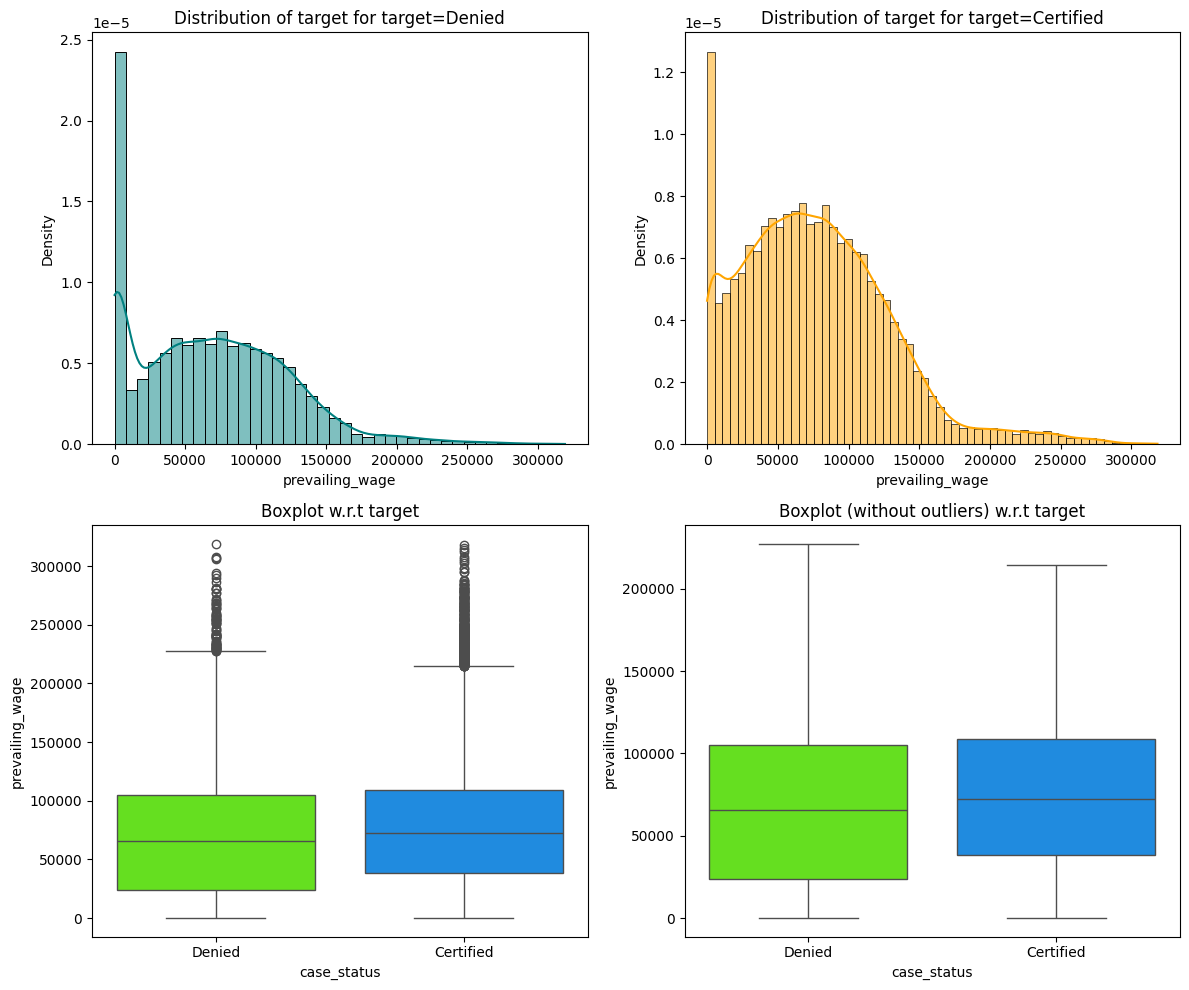

In [38]:
#Code for plot of Prevailing Wage vs Case Status
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

* They both look relatively similar, though the median for certified is a bit higher.

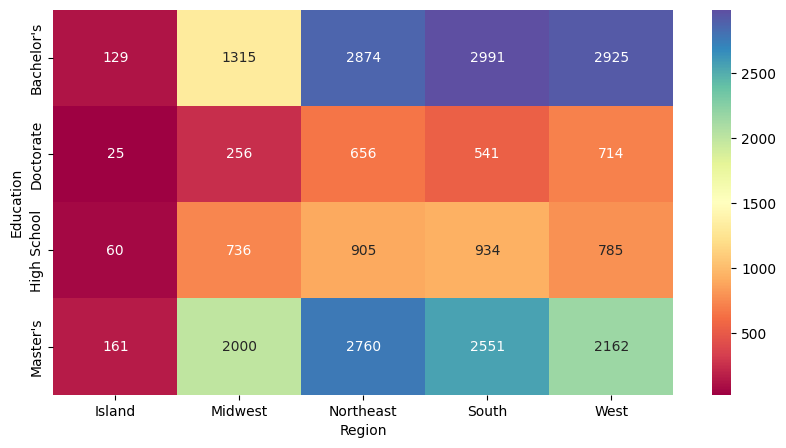

In [39]:
#Code to plot heatmap for the crosstab between education and region of employment
plt.figure(figsize=(10, 5))
sns.heatmap(pd.crosstab(df['education_of_employee'],df['region_of_employment']),
    annot=True,
    fmt="g",
    cmap="Spectral"
)
plt.ylabel("Education")
plt.xlabel("Region")
plt.show()

* Applicants with a Bachelor's seem to favor the South, West, and Northeast.
* Applicants with a Master's seem to favor the Northeast, South, and West.

requires_job_training      N     Y    All
has_job_experience                       
All                    22525  2955  25480
N                       8988  1690  10678
Y                      13537  1265  14802
------------------------------------------------------------------------------------------------------------------------


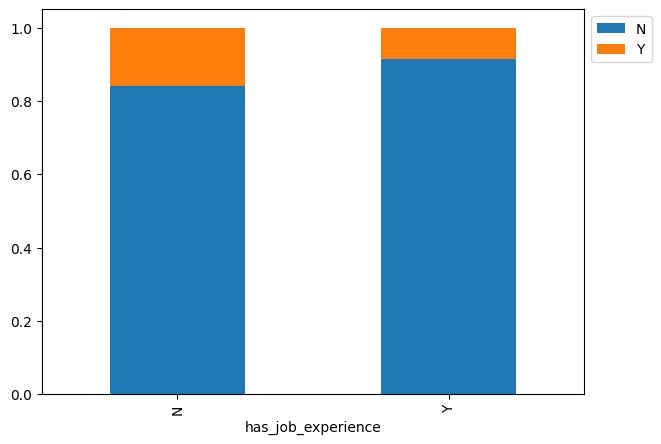

In [40]:
#Do the employees who have prior work experience require any job training?
#Code to plot Job Experience vs Job Training Requirement
stacked_barplot(df,"has_job_experience", "requires_job_training")

* Some applicants who have job experience had job training required, but the proportion is lower than those who don't have job experience requiring job training.

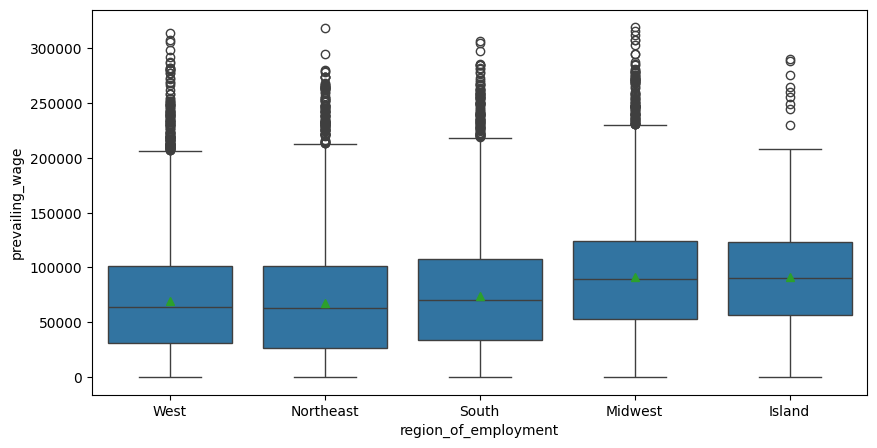

In [41]:
#Checking if the prevailing wage is similar across all the regions of the US
#Code for boxplot for region of employment and prevailing wage
plt.figure(figsize=(10, 5))
sns.boxplot(data=df,x='region_of_employment',y='prevailing_wage',showmeans=True)
plt.show()

*The Midwest and Island regions seem to have a higher median and mean prevailing wage than in other regions.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [42]:
#Code to make a copy of the dataset to preserve original data
data = df.copy()

* No missing values as noted previously, so missing value treatment not needed
* No duplicates as noted previously

Feature Engineering

In [43]:
#Code to make year established into years since established
data["yrs_estab"] = data["yr_of_estab"].apply(lambda x: 2016 - x)
data.drop("yr_of_estab", axis=1, inplace=True)
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yrs_estab
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,9
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,14
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,8
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,119
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,11


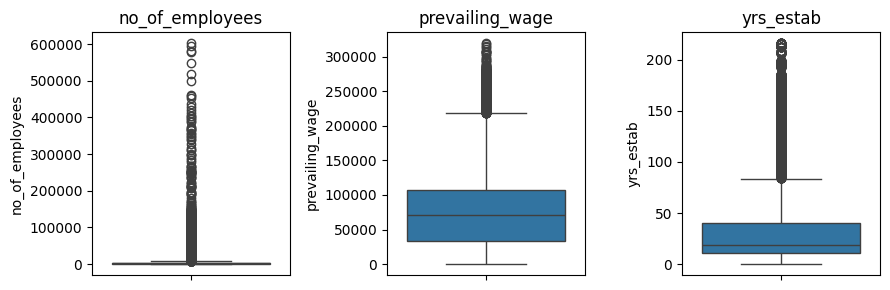

In [44]:
#Code for outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(9, 3))

for i, variable in enumerate(numeric_columns):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data[variable])
    plt.title(variable)

plt.tight_layout()
plt.show()

* There are outliers, but, since they're valid data points, they won't be treated.

In [45]:
#Code to change binary categorical variables to numeric
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)


In [46]:
#Code to change binary categorical variables to numeric
data['has_job_experience']=data['has_job_experience'].apply(lambda x: 1 if x == 'Y' else 0)

In [47]:
#Code to change binary categorical variables to numeric
data['requires_job_training']=data['requires_job_training'].apply(lambda x: 1 if x == 'Y' else 0)

In [48]:
#Code to change binary categorical variables to numeric
data['full_time_position']=data['full_time_position'].apply(lambda x: 1 if x == 'Y' else 0)

In [49]:
#Code to change education variable to numeric since it is ordinal
replaceStruct={"education_of_employee":{"High School": 1, "Bachelor's":2 , "Master's": 3, "Doctorate": 4,}}
data=data.replace(replaceStruct)

In [50]:
#Code to check that the previous steps went properly
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  int64  
 2   has_job_experience     25480 non-null  int64  
 3   requires_job_training  25480 non-null  int64  
 4   no_of_employees        25480 non-null  int64  
 5   region_of_employment   25480 non-null  object 
 6   prevailing_wage        25480 non-null  float64
 7   unit_of_wage           25480 non-null  object 
 8   full_time_position     25480 non-null  int64  
 9   case_status            25480 non-null  int64  
 10  yrs_estab              25480 non-null  int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 2.1+ MB


In [51]:
#Code to check that the previous steps went properly
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yrs_estab
0,Asia,1,0,0,14513,West,592.2029,Hour,1,0,9
1,Asia,3,1,0,2412,Northeast,83425.6500,Year,1,1,14
2,Asia,2,0,1,44444,West,122996.8600,Year,1,0,8
3,Asia,2,0,0,98,West,83434.0300,Year,1,0,119
4,Africa,3,1,0,1082,South,149907.3900,Year,1,1,11


* Those look converted correctly

In [52]:
#Code to get dummy variables
data=pd.get_dummies(data)
#Code to make everything float datatype
data=data.astype(float)
#Code to double-check the previous steps went through alright
data.head()

,education_of_employee,has_job_experience,requires_job_training,no_of_employees,prevailing_wage,full_time_position,case_status,yrs_estab,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,1.0,0.0,0.0,14513.0,592.2029,1.0,0.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,3.0,1.0,0.0,2412.0,83425.6500,1.0,1.0,14.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.0,0.0,1.0,44444.0,122996.8600,1.0,0.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2.0,0.0,0.0,98.0,83434.0300,1.0,0.0,119.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,3.0,1.0,0.0,1082.0,149907.3900,1.0,1.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [53]:
#Code to double-check everything is float datatype
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   education_of_employee           25480 non-null  float64
 1   has_job_experience              25480 non-null  float64
 2   requires_job_training           25480 non-null  float64
 3   no_of_employees                 25480 non-null  float64
 4   prevailing_wage                 25480 non-null  float64
 5   full_time_position              25480 non-null  float64
 6   case_status                     25480 non-null  float64
 7   yrs_estab                       25480 non-null  float64
 8   continent_Africa                25480 non-null  float64
 9   continent_Asia                  25480 non-null  float64
 10  continent_Europe                25480 non-null  float64
 11  continent_North America         25480 non-null  float64
 12  continent_Oceania               

* Everything is now float and dummy variables are good to proceed

In [54]:
#Code for data assignment for modeling
X = data.drop("case_status", axis=1)
Y = data["case_status"]

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3, random_state=1, stratify=Y)

In [55]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 22)
Shape of test set :  (7644, 22)
Percentage of classes in training set:
case_status
1.0    0.667919
0.0    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1.0    0.667844
0.0    0.332156
Name: proportion, dtype: float64


* Good proportion match between train and test sets

## Model Evaluation Criteria

### Model can make wrong predictions as:

1. Model predicts that the visa application will get certified but in reality, the visa application will get denied.
2. Model predicts that the visa application will get denied but in reality, the visa application will get certified.

### Which case is more important?
* Both the cases are important as:

* If a visa is predicted to be certified, but would actually get denied, then it's a waste of resources for both the entities processing the visa and applying for the visa.

* If a visa is predicted to be denied when it would actually be certified, then an entity would lose out on potential skilled workers.


### How to reduce the losses?

* `F1 Score` can be used a the metric for evaluation of the model, greater the F1  score higher are the chances of minimizing False Negatives and False Positives.


## Building Models

In [56]:
#Fitting the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

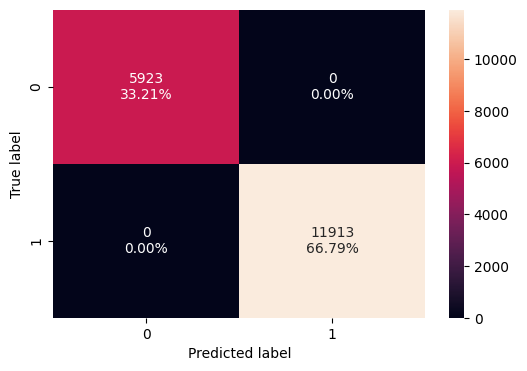

In [57]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(d_tree,X_train,y_train)

In [58]:
#Code to check model performance on train data
d_tree_model_train_perf=model_performance_classification_sklearn(d_tree,X_train,y_train)
print("Training performance:\n",d_tree_model_train_perf)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


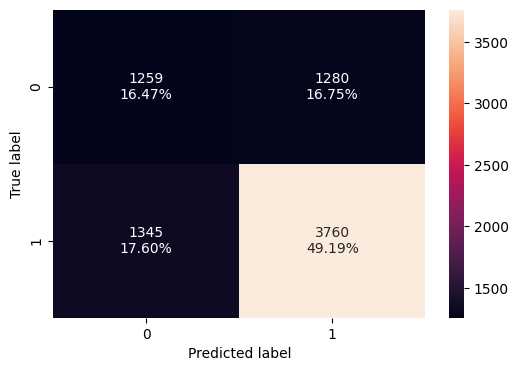

In [59]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(d_tree,X_test,y_test)

In [60]:
#Check model performance on test data
d_tree_model_test_perf=model_performance_classification_sklearn(d_tree,X_test,y_test)
print("Testing performance:\n",d_tree_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.656593  0.736533   0.746032  0.741252


Observations:
* Very much overfitted as we can see from the training model being 1.0 and the marked difference between the test and train metrics

Tuning Decision Tree

In [61]:
# Choose the type of classifier.
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(10, 20, 5),
    "min_samples_leaf": [3, 5],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10, max_leaf_nodes=2,
                       min_impurity_decrease=0.0001, min_samples_leaf=3,
                       random_state=1)

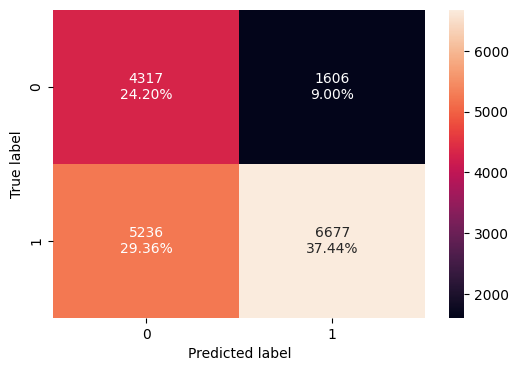

In [62]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(dtree_estimator,X_train,y_train)

In [63]:
#Code to check model performance on train data
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator,X_train,y_train)
print("Training performance:\n",dtree_estimator_model_train_perf)

Training performance:
    Accuracy   Recall  Precision       F1
0  0.616394  0.56048   0.806109  0.66122


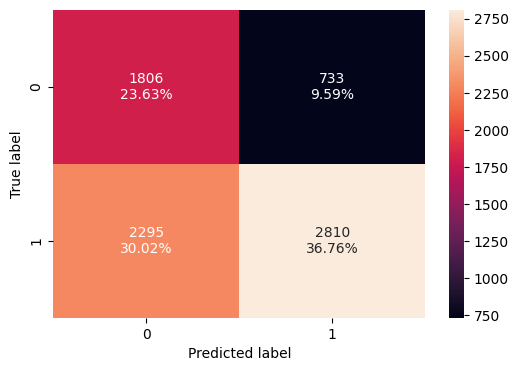

In [64]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(dtree_estimator,X_test,y_test)

In [65]:
#Check model performance on test data
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator,X_test,y_test)
print("Testing performance:\n",dtree_estimator_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.603872  0.550441   0.793113  0.649861


Observations:
* Tuning the decision tree does give a more generalized result where it is much more consistent between test and train sets.
* F1 is 0.64 for the test which isn't great

Bagging

In [66]:
#Fitting the model
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train,y_train)

BaggingClassifier(random_state=1)

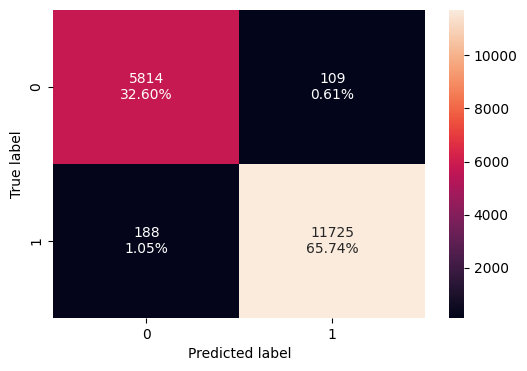

In [67]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(bagging_classifier,X_train,y_train)

In [68]:
#Check model performance on train data
bagging_classifier_model_train_perf=model_performance_classification_sklearn(bagging_classifier,X_train,y_train)
print(bagging_classifier_model_train_perf)

   Accuracy    Recall  Precision        F1
0  0.983348  0.984219   0.990789  0.987493


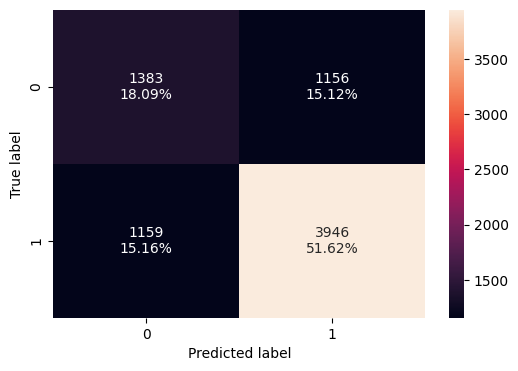

In [69]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(bagging_classifier,X_test,y_test)

In [70]:
#Check model performance on test data
bagging_classifier_model_test_perf=model_performance_classification_sklearn(bagging_classifier,X_test,y_test)
print(bagging_classifier_model_test_perf)

   Accuracy    Recall  Precision        F1
0  0.697148  0.772968   0.773422  0.773195


Observations:
* Bagging also results in overfitting as the training metrics are high, but the test metrics don't match.
* The F1 is 0.77 for the test data which is better than the previous model

Tuning Bagging

In [71]:
# Choose the type of classifier.
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {"max_samples": [0.7, 0.8],
              "max_features": [0.5,0.7,1],
              "n_estimators": np.arange(50,110,25),
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.5, max_samples=0.7, n_estimators=100,
                  random_state=1)

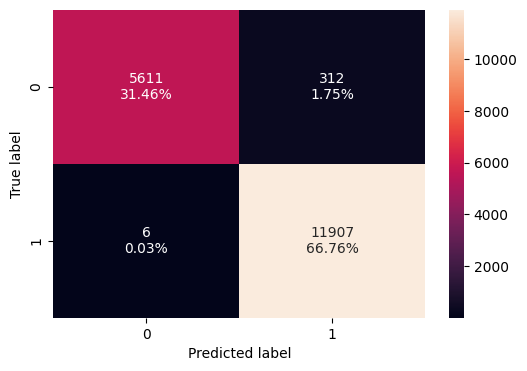

In [72]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(bagging_estimator_tuned,X_train,y_train)

In [73]:
#Check model performance on train data
bagging_estimator_tuned_model_train_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_train,y_train)
print(bagging_estimator_tuned_model_train_perf)

   Accuracy    Recall  Precision        F1
0  0.982171  0.999496   0.974466  0.986822


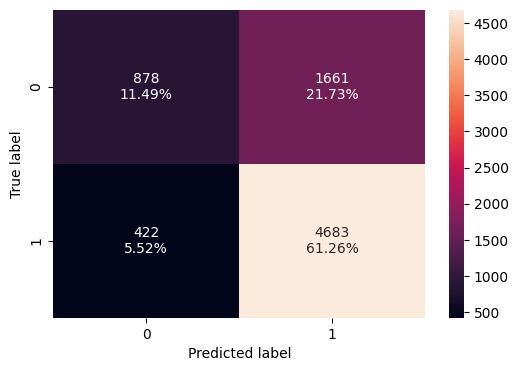

In [74]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(bagging_estimator_tuned,X_test,y_test)

In [75]:
#Check model performance on test data
bagging_estimator_tuned_model_test_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_test,y_test)
print(bagging_estimator_tuned_model_test_perf)

   Accuracy    Recall  Precision        F1
0  0.727499  0.917336   0.738178  0.818063


Observations:
* After tuning, Bagging Classifier still shows overfitting as train metrics improved closer to being perfect.
* However, it looks like generalization has improved a bit as F1 also increased to 0.81.
* Also, 0.91 Recall which is much better than the 0.77 before tuning.

Random Forest

In [76]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1,class_weight="balanced")
rf_estimator.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

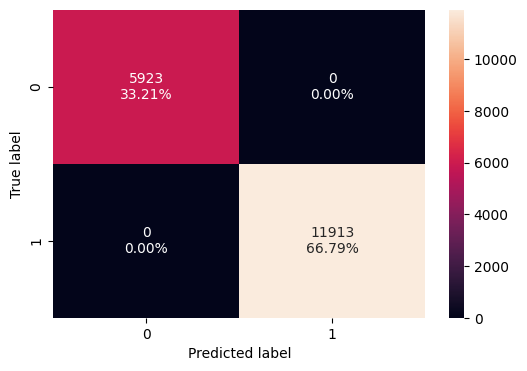

In [77]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(rf_estimator,X_train,y_train)

In [78]:
#Check model performance on train data
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


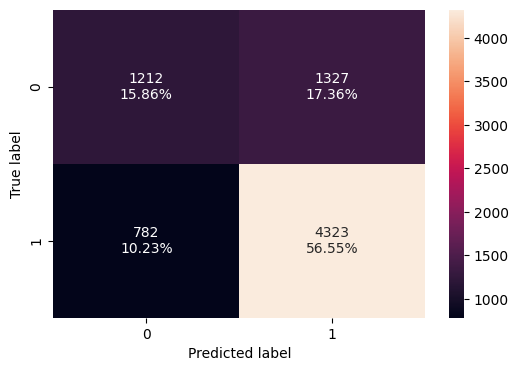

In [79]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

In [80]:
#Check model performance on test data
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.724097  0.846817   0.765133  0.803905


Observations:
*Also, overfitting as training is 1.0, but test metrics don't match that.
* F1 is 0.80 which is similar to the previous tuned model. This model has lower recall though.

Tuning Random Forest

In [81]:
# Choose the type of classifier.
#The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y))
rf_tuned = RandomForestClassifier(random_state=1,oob_score=True,bootstrap=True)

parameters = {"class_weight": ["balanced", None],
              "max_depth": list(np.arange(5, 15, 5)),
              "max_features": ["sqrt", "log2"],
              "min_samples_split": [3, 5, 7],
              "n_estimators": np.arange(10, 40, 10),}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=20,
                       oob_score=True, random_state=1)

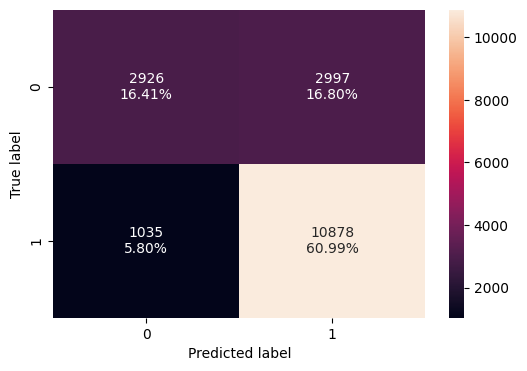

In [82]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(rf_tuned,X_train,y_train)

In [83]:
#Check model performance on train data
rf_tuned_model_train_perf=model_performance_classification_sklearn(rf_tuned,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train_perf)

Training performance:
    Accuracy   Recall  Precision        F1
0   0.77394  0.91312      0.784  0.843648


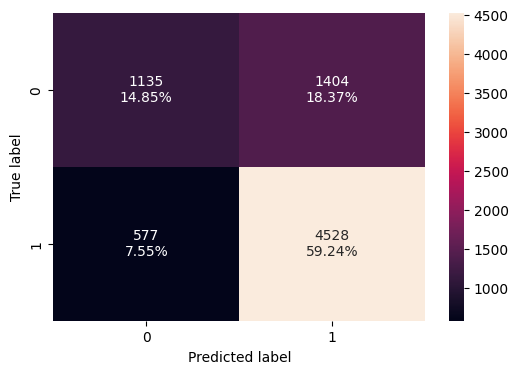

In [84]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(rf_tuned,X_test,y_test)

In [85]:
#Check model performance on test data
rf_tuned_model_test_perf=model_performance_classification_sklearn(rf_tuned,X_test,y_test)
print("Testing performance:\n",rf_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.740842  0.886974   0.763318  0.820513


Observations:
* After tuning, seems to have better generalization. Now, model is not as overfitted since train set doesn't reflect a perfect score.
* Also, improved both F1 and Recall.

Boosting

Adaboost

In [86]:
#Fitting the model
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier.fit(X_train,y_train)

AdaBoostClassifier(random_state=1)

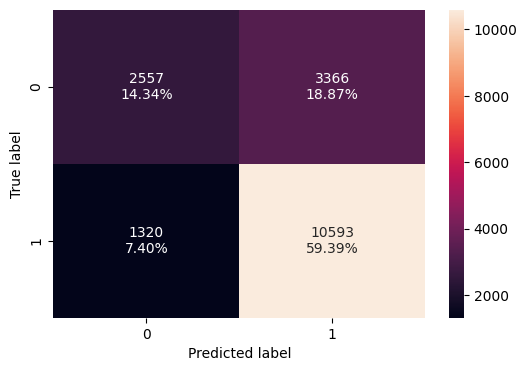

In [87]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(ab_classifier,X_train,y_train)

In [88]:
#Check model performance on train data
ab_classifier_model_train_perf=model_performance_classification_sklearn(ab_classifier,X_train,y_train)
print(ab_classifier_model_train_perf)

   Accuracy    Recall  Precision        F1
0  0.737273  0.889197   0.758865  0.818878


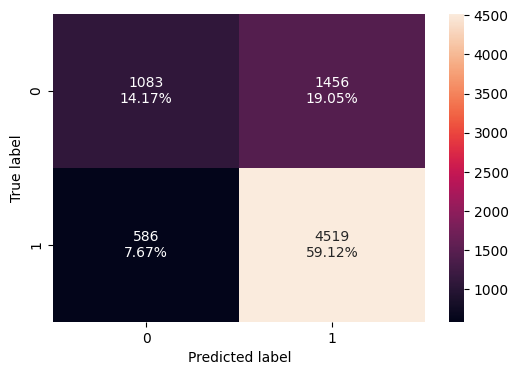

In [89]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(ab_classifier,X_test,y_test)

In [90]:
#Check model performance on test data
ab_classifier_model_test_perf=model_performance_classification_sklearn(ab_classifier,X_test,y_test)
print(ab_classifier_model_test_perf)

   Accuracy    Recall  Precision        F1
0  0.732862  0.885211   0.756318  0.815704


Observations:
* This model has good generalization as test and train metrics are pretty close.
* Good F1 of 0.815 and recall of 0.885

 Tuning AdaBoost

In [91]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    #Let's try different max_depth for base_estimator
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
        ],
}

# Type of scoring used to compare parameter  combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.05, n_estimators=100, random_state=1)

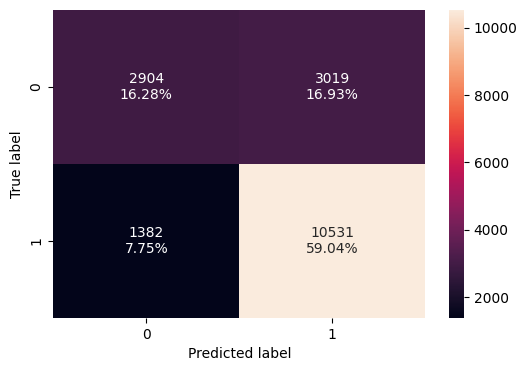

In [92]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(abc_tuned,X_train,y_train)

In [93]:
#Check model performance on train data
abc_tuned_model_train_perf=model_performance_classification_sklearn(abc_tuned,X_train,y_train)
print(abc_tuned_model_train_perf)

   Accuracy    Recall  Precision        F1
0  0.753252  0.883992   0.777196  0.827161


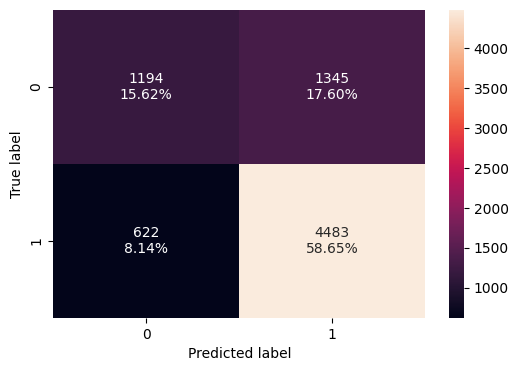

In [94]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(abc_tuned,X_test,y_test)

In [95]:
#Check model performance on test data
abc_tuned_model_test_perf=model_performance_classification_sklearn(abc_tuned,X_test,y_test)
print(abc_tuned_model_test_perf)

   Accuracy    Recall  Precision        F1
0  0.742674  0.878159   0.769218  0.820086


Observations:
* After tuning, still has good generalization.
* F1 has increased to 0.820, but recall went down to 0.878

Gradient Boosting

In [96]:
#Fitting the model
gb_classifier = GradientBoostingClassifier(random_state=1)
gb_classifier.fit(X_train,y_train)

GradientBoostingClassifier(random_state=1)

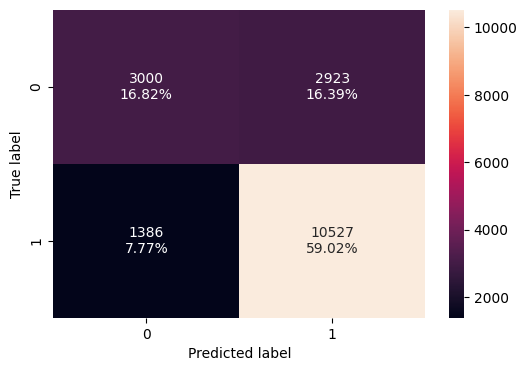

In [97]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(gb_classifier,X_train,y_train)

In [98]:
#Check model performance on train data
gb_classifier_model_train_perf=model_performance_classification_sklearn(gb_classifier,X_train,y_train)
print("Training performance:\n",gb_classifier_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0   0.75841  0.883657   0.782677  0.830107


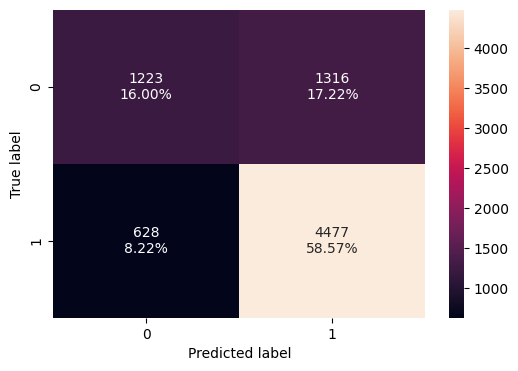

In [99]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(gb_classifier,X_test,y_test)

In [100]:
#Check model performance on test data
gb_classifier_model_test_perf=model_performance_classification_sklearn(gb_classifier,X_test,y_test)
print("Testing performance:\n",gb_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.745683  0.876983   0.772829  0.821619


Observations:
* Has good generalization as test and train are comparable.
* Good F1 at 0.821 and recall at 0.876
* Seems like a good contender for final model.

Tuning Gradient Boosting

In [101]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
   }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=50, random_state=1,
                           subsample=0.7)

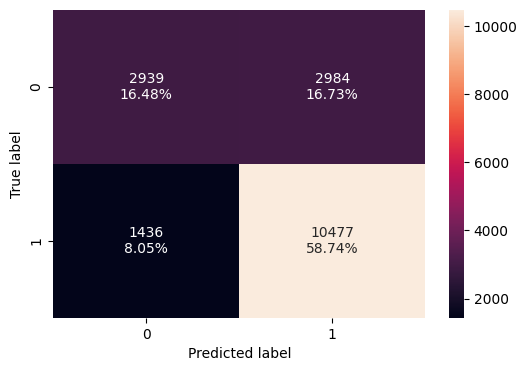

In [102]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(gbc_tuned,X_train,y_train)

In [103]:
#Check model performance on train data
gbc_tuned_model_train_perf=model_performance_classification_sklearn(gbc_tuned,X_train,y_train)
print("Training performance:\n",gbc_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.752187  0.879459   0.778323  0.825806


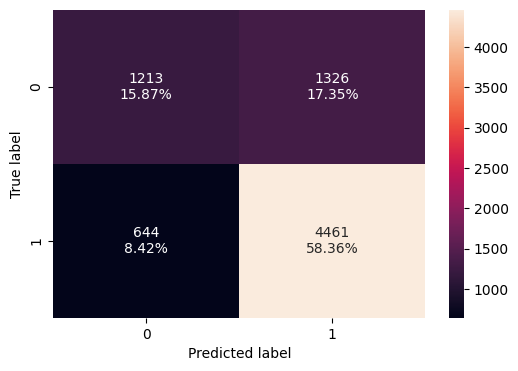

In [104]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(gbc_tuned,X_test,y_test)

In [105]:
#Check model performance on test data
gbc_tuned_model_test_perf=model_performance_classification_sklearn(gbc_tuned,X_test,y_test)
print("Testing performance:\n",gbc_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.742282  0.873849   0.770866  0.819133


* After tuning, still good generalization.
* However F1 and Recall have decreased slightly which isn't what we want.

XGBoost

In [106]:
#Fitting the model
xgb_classifier = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_classifier.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

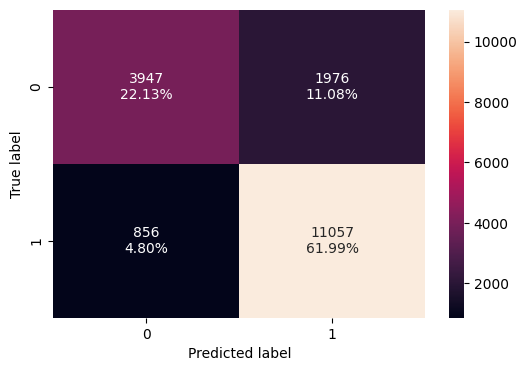

In [122]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(xgb_classifier,X_train,y_train)

In [123]:
#Check model performance on train data
xgb_classifier_model_train_perf=model_performance_classification_sklearn(xgb_classifier,X_train,y_train)
print("Training performance:\n",xgb_classifier_model_train_perf)


Training performance:
    Accuracy    Recall  Precision        F1
0   0.84122  0.928146   0.848385  0.886475


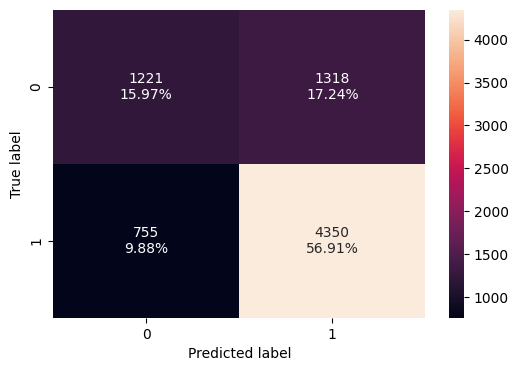

In [124]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(xgb_classifier,X_test,y_test)


In [125]:
#Check model performance on test data
xgb_classifier_model_test_perf=model_performance_classification_sklearn(xgb_classifier,X_test,y_test)
print("Testing performance:\n",xgb_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.728807  0.852106   0.767466  0.807574


Observations:
* XG Boost seems less generalized than some previous models since there's a bigger gap between test and train metrics.
* F1 is 0.807 and recall is 0.852 which is less than the previous model.

Tuning XGBoost

In [109]:
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')

# Grid of parameters to choose from
parameters = {
   'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.9,1]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters,scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

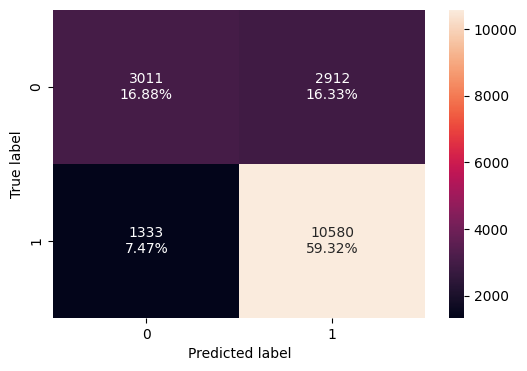

In [110]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(xgb_tuned,X_train,y_train)

In [111]:
#Check model performance on train data
xgb_tuned_model_train_perf=model_performance_classification_sklearn(xgb_tuned,X_train,y_train)
print("Training performance:\n",xgb_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.761998  0.888105   0.784168  0.832907


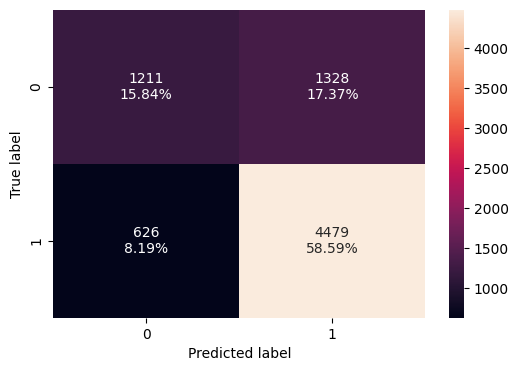

In [112]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(xgb_tuned,X_test,y_test)

In [113]:
#Check model performance on test data
xgb_tuned_model_test_perf=model_performance_classification_sklearn(xgb_tuned,X_test,y_test)
print("Testing performance:\n",xgb_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.744375  0.877375    0.77131  0.820931


Observations:
* After tuning, it is more generalized which is good.
* F1 and recall have both also increased to 0.820 and 0.877, respecively. So, this is a good contender as well.

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

##  Stacking

Stacking

In [114]:
estimators = [('Random Forest',rf_tuned), ('Gradient Boosting',gbc_tuned), ('Decision Tree',dtree_estimator)]

final_estimator = xgb_tuned

stacking_classifier= StackingClassifier(estimators=estimators,final_estimator=final_estimator)

stacking_classifier.fit(X_train,y_train)

StackingClassifier(estimators=[('Random Forest',
                                RandomForestClassifier(max_depth=10,
                                                       min_samples_split=5,
                                                       n_estimators=20,
                                                       oob_score=True,
                                                       random_state=1)),
                               ('Gradient Boosting',
                                GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                                           max_features=0.7,
                                                           n_estimators=50,
                                                           random_state=1,
                                                           subsample=0.7)),
                               ('Decision Tree',
                                DecisionTreeClassifier(class_wei...
                                                 feature_types=None, gamma=3,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=50, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=1, ...))

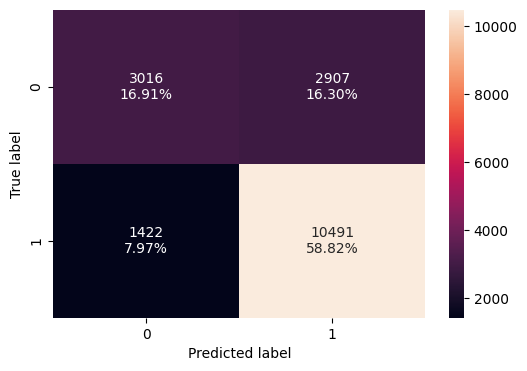

In [115]:
#Creating confusion matrix for train data
confusion_matrix_sklearn(stacking_classifier,X_train,y_train)

In [116]:
#Check model performance on train data
stacking_classifier_model_train_perf=model_performance_classification_sklearn(stacking_classifier,X_train,y_train)
print("Training performance:\n",stacking_classifier_model_train_perf)


Training performance:
    Accuracy    Recall  Precision        F1
0  0.757289  0.880635   0.783027  0.828968


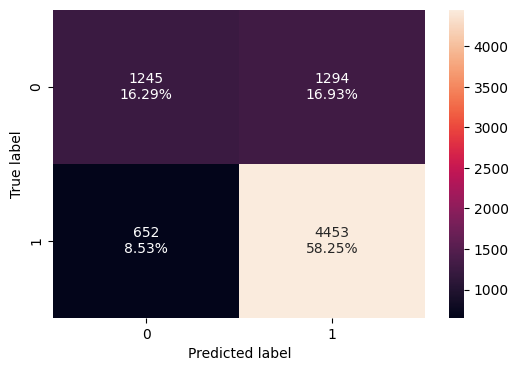

In [117]:
#Creating confusion matrix for test data
confusion_matrix_sklearn(stacking_classifier,X_test,y_test)

In [118]:
#Check model performance on test data
stacking_classifier_model_test_perf=model_performance_classification_sklearn(stacking_classifier,X_test,y_test)
print("Testing performance:\n",stacking_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.745421  0.872282   0.774839  0.820678


Obeservations:
* Stacking is also a good contender. It is similarly generalized with F1 of 0.820 and Recall of 0.872.

## Model Performance Comparison and Conclusions

In [119]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        d_tree_model_train_perf.T,
        dtree_estimator_model_train_perf.T,
        bagging_classifier_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_classifier_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gb_classifier_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_classifier_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        stacking_classifier_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]
print("Training Performance Comparison:")
models_train_comp_df

Training Performance Comparison:


,Decision Tree,Tuned Decision Tree,Bagging Classifier,Tuned Bagging Classifier,Random Forest,Tuned Random Forest,Adaboost Classifier,Tuned Adaboost Classifier,Gradient Boost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,1.0,0.616394,0.983348,0.982171,1.0,0.773940,0.737273,0.753252,0.758410,0.752187,0.841220,0.761998,0.757289
Recall,1.0,0.560480,0.984219,0.999496,1.0,0.913120,0.889197,0.883992,0.883657,0.879459,0.928146,0.888105,0.880635
Precision,1.0,0.806109,0.990789,0.974466,1.0,0.784000,0.758865,0.777196,0.782677,0.778323,0.848385,0.784168,0.783027
F1,1.0,0.661220,0.987493,0.986822,1.0,0.843648,0.818878,0.827161,0.830107,0.825806,0.886475,0.832907,0.828968


In [120]:
#Code for Test Performance Comparison

models_test_comp_df = pd.concat(
    [
        d_tree_model_test_perf.T,
        dtree_estimator_model_test_perf.T,
        bagging_classifier_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_classifier_model_test_perf.T,
        abc_tuned_model_test_perf.T,
        gb_classifier_model_test_perf.T,
        gbc_tuned_model_test_perf.T,
        xgb_classifier_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        stacking_classifier_model_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]
print("Test Performance Comparison:")
models_test_comp_df

Test Performance Comparison:


,Decision Tree,Tuned Decision Tree,Bagging Classifier,Tuned Bagging Classifier,Random Forest,Tuned Random Forest,Adaboost Classifier,Tuned Adaboost Classifier,Gradient Boost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,0.656593,0.603872,0.697148,0.727499,0.724097,0.740842,0.732862,0.742674,0.745683,0.742282,0.728807,0.744375,0.745421
Recall,0.736533,0.550441,0.772968,0.917336,0.846817,0.886974,0.885211,0.878159,0.876983,0.873849,0.852106,0.877375,0.872282
Precision,0.746032,0.793113,0.773422,0.738178,0.765133,0.763318,0.756318,0.769218,0.772829,0.770866,0.767466,0.771310,0.774839
F1,0.741252,0.649861,0.773195,0.818063,0.803905,0.820513,0.815704,0.820086,0.821619,0.819133,0.807574,0.820931,0.820678


Observations:
* For the final model, Gradient Booster Classifier will be chosen as it is generalized well and has the highest F1 at 0.821.

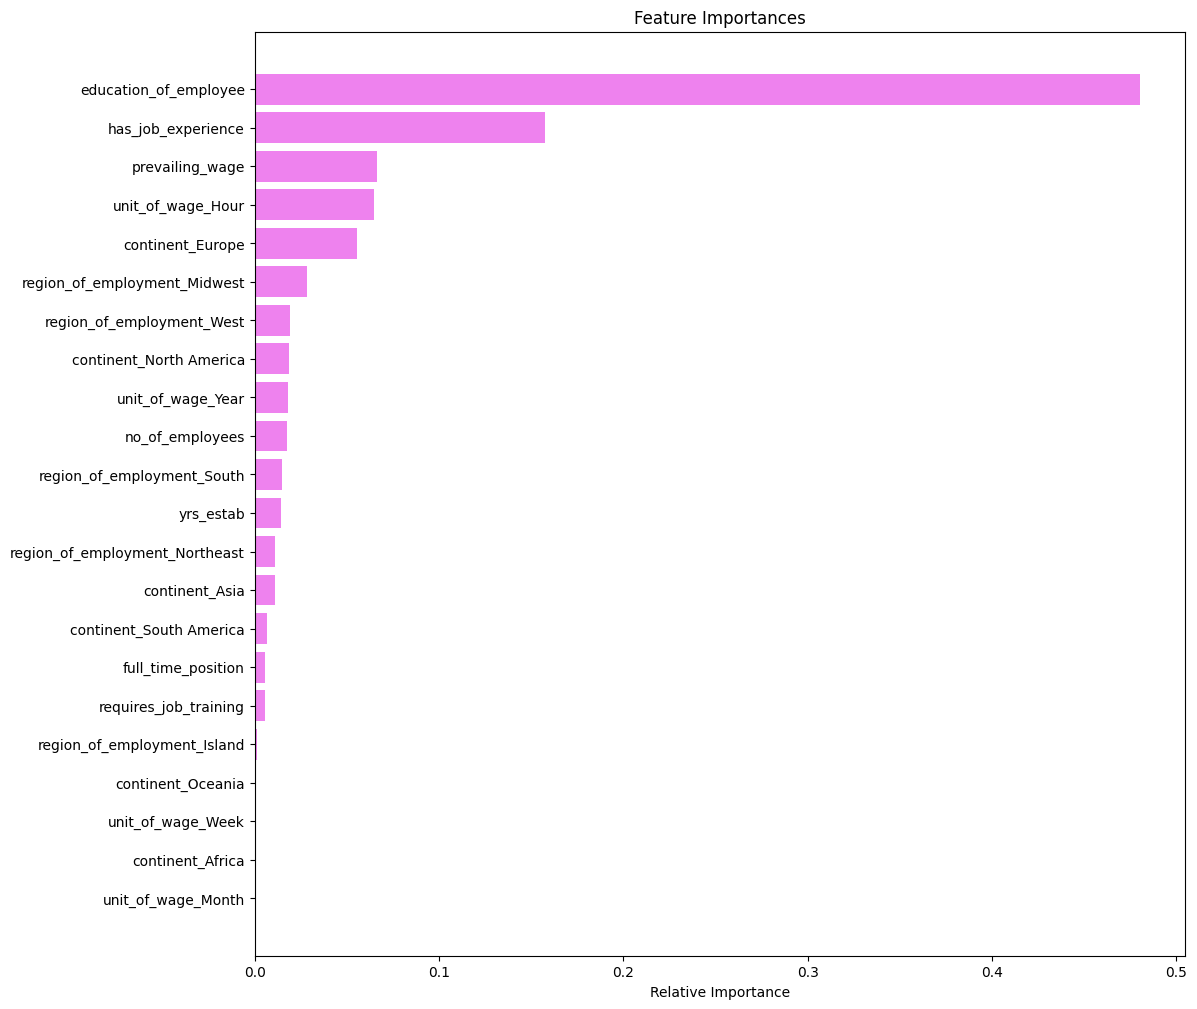

In [121]:
#Code for Important features of the final model
feature_names = X_train.columns
importances = gb_classifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observations:
* Education of employee and job experience are the most important features for this model
* Prevailing wage comes in at third among strong predictors

## Actionable Insights and Recommendations

* The final model which seems the most apt for adopting would be the Gradient Boosting Classifier as it has a high F1 and is well generalized between train and test datasets.
* Emphasize education level and job experience. Those are shown to be important predictors in visa certification. People with higher levels of education seem to have a higher chance of visa certification. Bachelor's Degree and Master's are the majority. This may be because higher skilled people are likely the target to bring in. Job experience is also helpful as those with work experience had higher levels of approvals. This could be because it demonstrates professional readiness.
* Prevailing wage was also an important predictor, with the around
70k dollars mark being a good area for indication of visa certification.
* Would recommend gathering more data, but standardizing the units for prevailing to year as it seems to be the most commonly used. Collecting country data could be interesting as well since it could allow for better insights than the broader category of continent.
* Also, would check on data collection because number of employees had negative values and there were some oddities with the other prevailing wage values for those with units other than year such as applicants having 500+ dollar hourly wages or $30k weekly/monthly wages  which doesn't read as realistic.

In [127]:
!jupyter nbconvert /content/drive/MyDrive/Python/JA_EasyVisa_Fullcode.ipynb --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Python/JA_EasyVisa_Fullcode.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 48 image(s).
[NbConvertApp] Writing 2320335 bytes to /content/drive/MyDrive/Python/JA_EasyVisa_Fullcode.html
